# Projet N14 - Prediction du Turnover des Auditeurs Internes

**Etablissement** : ENCG Settat  
**Option** : Controle, Audit et Conseil  
**Module** : Intelligence Artificielle  
**Année** : 2025-2026
 **Réalisé par** : KIHEL Hajar / Nada Houmadi
---

## Description du projet

Ce projet applique le Machine Learning pour predire si un auditeur interne est susceptible de quitter l'organisation dans les 12 mois a venir.

- **Type de tache** : Classification binaire supervisee
- **Variable cible** : Attrition (1 = depart, 0 = reste)
- **Dataset** : IBM HR Analytics Employee Attrition (Kaggle)

---

## Plan du Notebook

1. Installation et importation des bibliotheques  
2. Chargement des donnees  
3. Exploration des donnees (EDA)  
4. Pretraitement des donnees  
5. Modelisation  
6. Evaluation et comparaison des modeles  
7. Interpretabilite avec SHAP  
8. Recommandations metier

---
## Etape 1 - Installation et Importation des Bibliotheques

In [ ]:
# Installation des bibliotheques supplementaires
!pip install imbalanced-learn xgboost shap lightgbm --quiet

In [ ]:
# Manipulation des donnees
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Pretraitement
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Modeles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

# Equilibrage des classes
from imblearn.over_sampling import SMOTE

# Interpretabilite
import shap

# Configuration generale
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Toutes les bibliotheques ont ete importees avec succes.')

Toutes les bibliotheques ont ete importees avec succes.


---
## Etape 2 - Chargement des Donnees

In [ ]:
# Chargement du dataset IBM HR Analytics
import pandas as pd
import urllib.request
import io

# Chemin vers ton fichier Google Drive
file_path = "/content/drive/MyDrive/Projet 2026/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = None

# Essayer de charger depuis Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    df = pd.read_csv(file_path)
    print(f"Dataset chargé depuis Google Drive : {file_path}")
except Exception as e:
    print(f"Google Drive échoué : {e}")

# Si Drive échoue, essayer depuis Kaggle/URL en ligne
if df is None:
    urls = [
        "https://raw.githubusercontent.com/dsrscientist/dataset1/master/WA_Fn-UseC_-HR-Employee-Attrition.csv",
        "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
    ]
    for url in urls:
        try:
            df = pd.read_csv(url)
            print(f"Dataset chargé depuis : {url}")
            break
        except Exception as e:
            print(f"URL échouée : {url} -> {e}")

# Si tout échoue, upload manuel
if df is None:
    print("\nTOUTES LES SOURCES ONT ÉCHOUÉ.")
    print("Uploadez le fichier manuellement :")
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

if df is not None:
    print(f"Nombre de lignes   : {df.shape[0]}")
    print(f"Nombre de colonnes : {df.shape[1]}")
    print("Colonnes disponibles :", list(df.columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset chargé depuis Google Drive : /content/drive/MyDrive/Projet 2026/WA_Fn-UseC_-HR-Employee-Attrition.csv
Nombre de lignes   : 1470
Nombre de colonnes : 35
Colonnes disponibles : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Apercu des premieres lignes
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Informations generales sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Statistiques descriptives des variables numeriques
df.describe()

AttributeError: 'NoneType' object has no attribute 'describe'

---
## Etape 3 - Exploration des Donnees (EDA)

In [ ]:
# Verification des valeurs manquantes
valeurs_manquantes = df.isnull().sum()
print('Valeurs manquantes par colonne :')
if valeurs_manquantes.sum() == 0:
    print('Aucune valeur manquante detectee.')
else:
    print(valeurs_manquantes[valeurs_manquantes > 0])

Valeurs manquantes par colonne :
Aucune valeur manquante detectee.


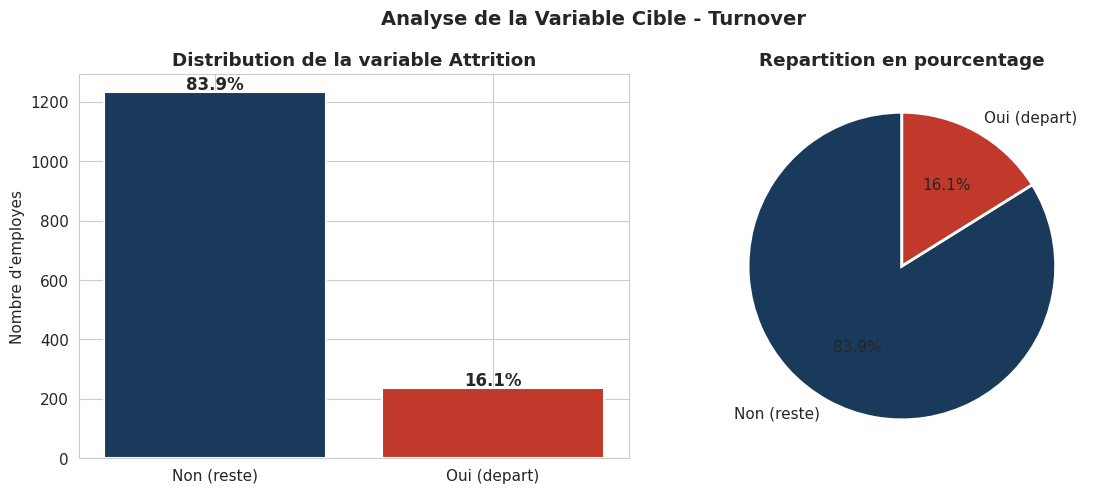

Taux de depart : 16.1% -> desequilibre de classes detecte.
Solution : application de SMOTE lors du pretraitement.


In [ ]:
# Distribution de la variable cible : Attrition
counts = df['Attrition'].value_counts()
pcts   = df['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Diagramme en barres
barres = axes[0].bar(
    ['Non (reste)', 'Oui (depart)'],
    counts.values,
    color=['#1a3a5c', '#c0392b'],
    edgecolor='white',
    linewidth=1.5
)
for barre, pct in zip(barres, pcts.values):
    axes[0].text(
        barre.get_x() + barre.get_width() / 2,
        barre.get_height() + 8,
        f'{pct:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )
axes[0].set_title('Distribution de la variable Attrition', fontweight='bold')
axes[0].set_ylabel("Nombre d'employes")

# Diagramme circulaire
axes[1].pie(
    counts.values,
    labels=['Non (reste)', 'Oui (depart)'],
    autopct='%1.1f%%',
    colors=['#1a3a5c', '#c0392b'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Repartition en pourcentage', fontweight='bold')

plt.suptitle('Analyse de la Variable Cible - Turnover', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Taux de depart : {pcts["Yes"]:.1f}% -> desequilibre de classes detecte.')
print('Solution : application de SMOTE lors du pretraitement.')

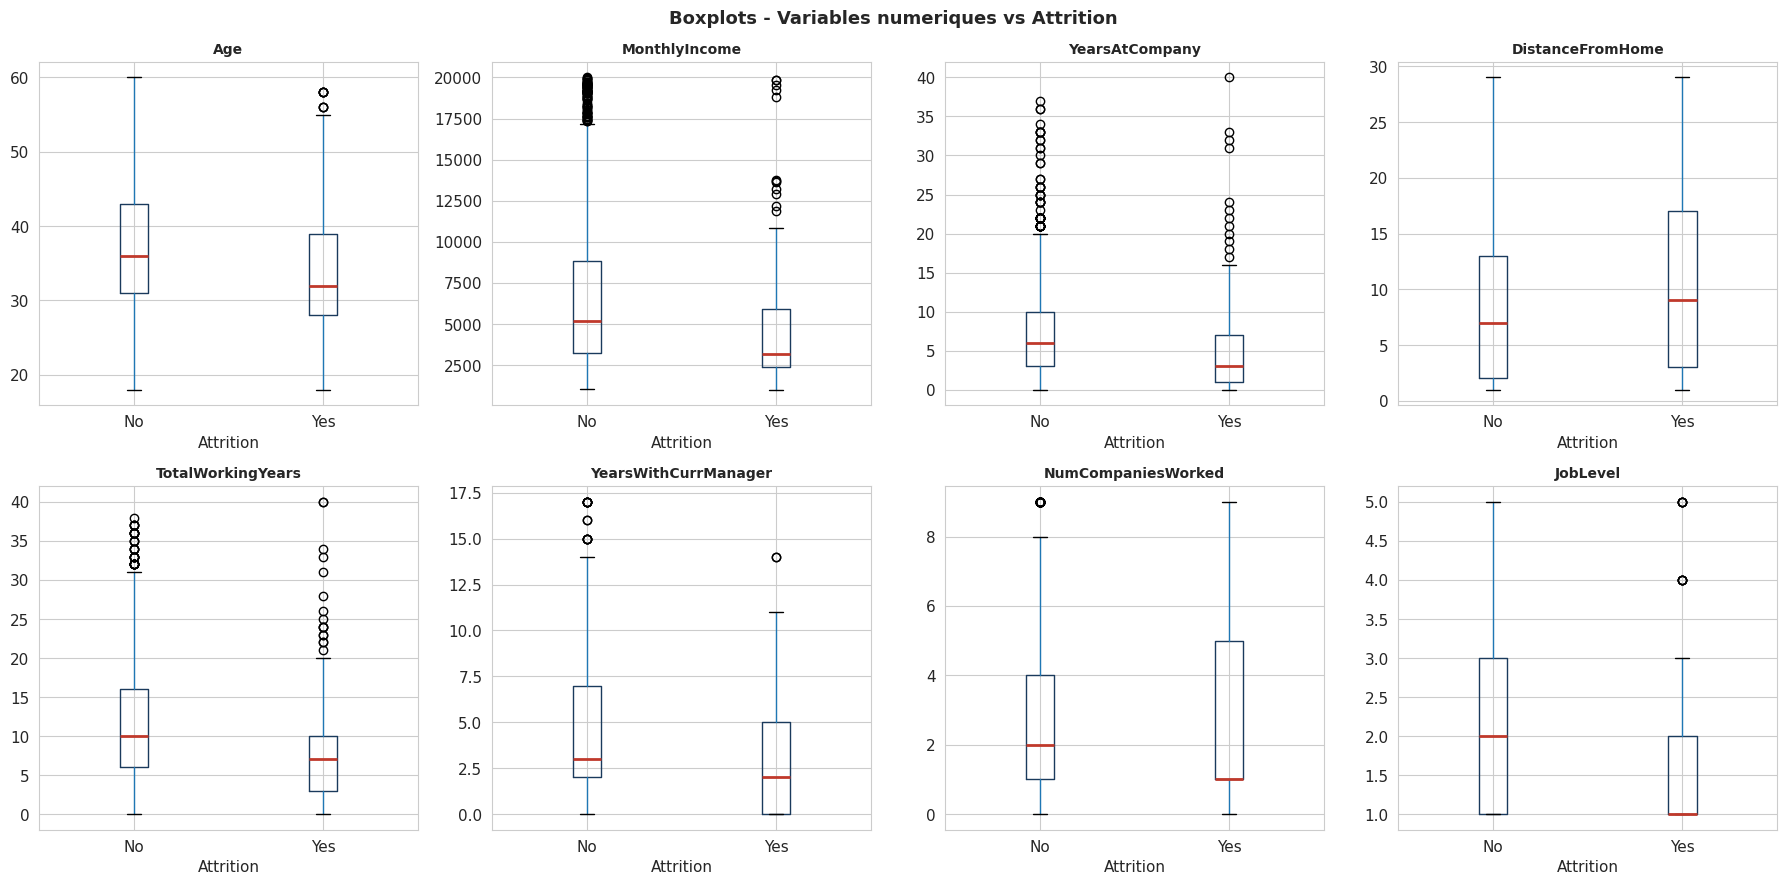

In [ ]:
# Boxplots des variables numeriques selon l'Attrition
variables_num = [
    'Age', 'MonthlyIncome', 'YearsAtCompany',
    'DistanceFromHome', 'TotalWorkingYears',
    'YearsWithCurrManager', 'NumCompaniesWorked', 'JobLevel'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, var in enumerate(variables_num):
    df.boxplot(
        column=var, by='Attrition', ax=axes[i],
        boxprops=dict(color='#1a3a5c'),
        medianprops=dict(color='#c0392b', linewidth=2)
    )
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Attrition')

plt.suptitle('Boxplots - Variables numeriques vs Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

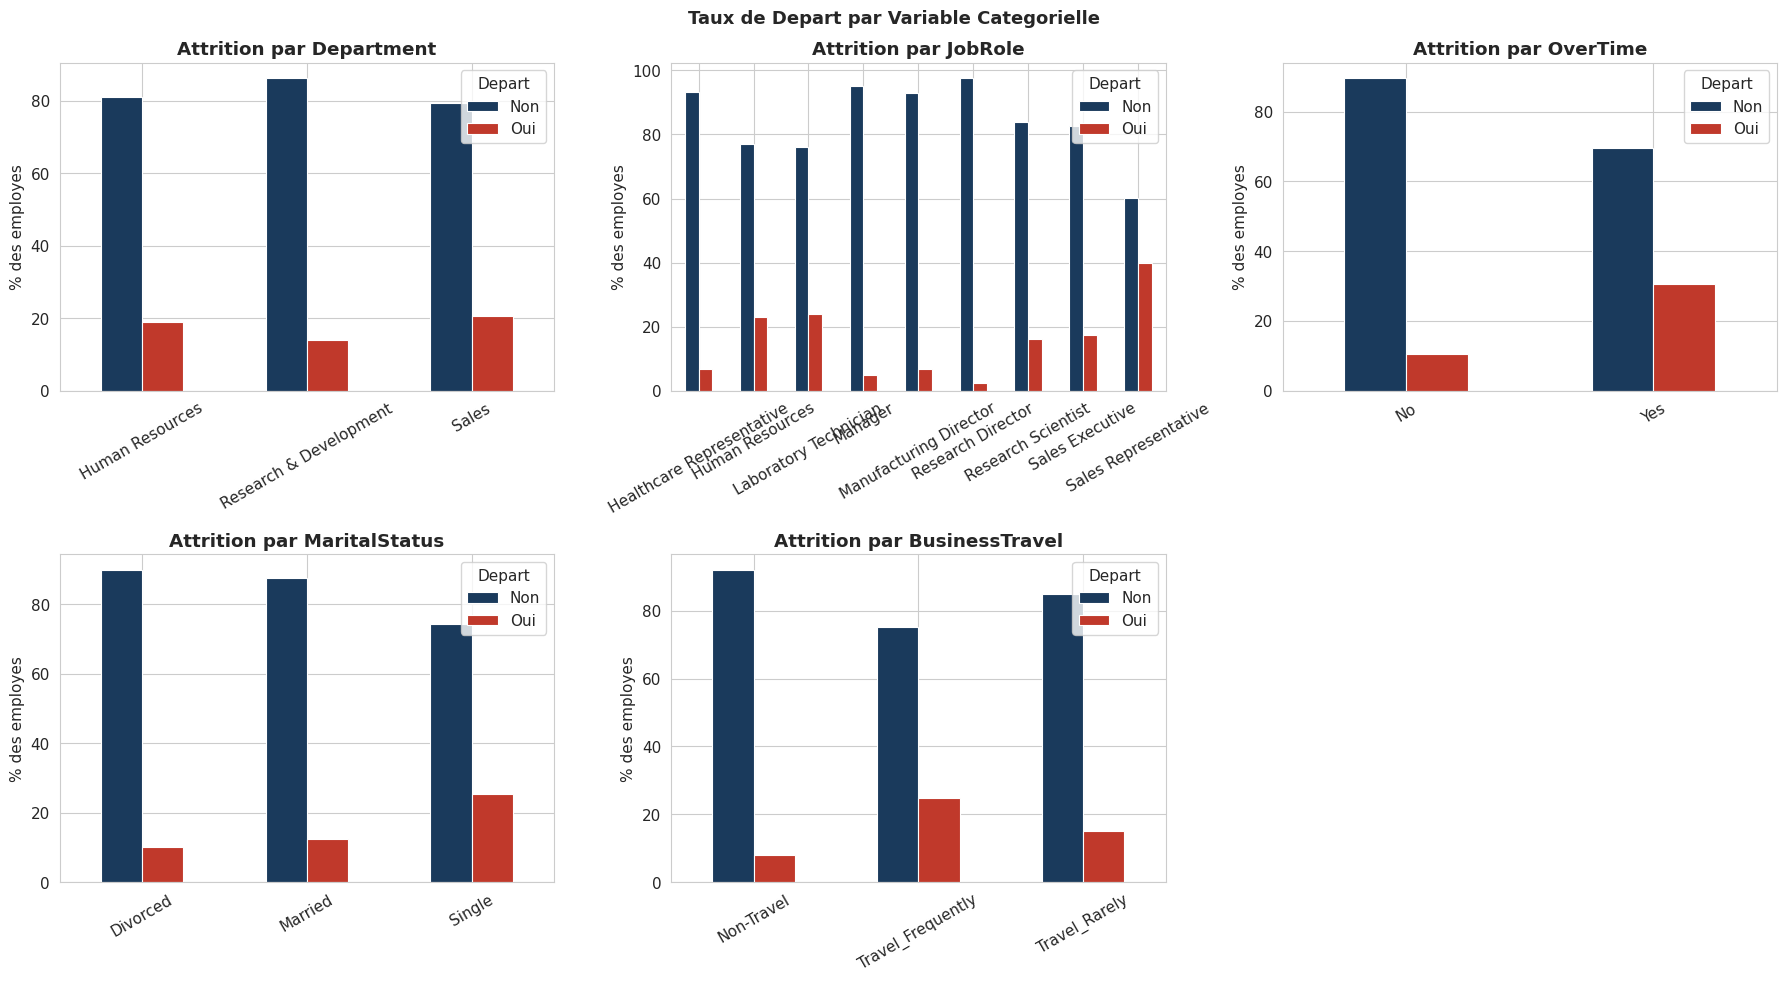

In [ ]:
# Taux d'attrition par variable categorielle
variables_cat = ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'BusinessTravel']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(variables_cat):
    ct = pd.crosstab(df[var], df['Attrition'], normalize='index') * 100
    ct.plot(
        kind='bar', ax=axes[i],
        color=['#1a3a5c', '#c0392b'],
        edgecolor='white', linewidth=0.8
    )
    axes[i].set_title(f'Attrition par {var}', fontweight='bold')
    axes[i].set_ylabel('% des employes')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Non', 'Oui'], title='Depart')

axes[-1].axis('off')
plt.suptitle('Taux de Depart par Variable Categorielle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

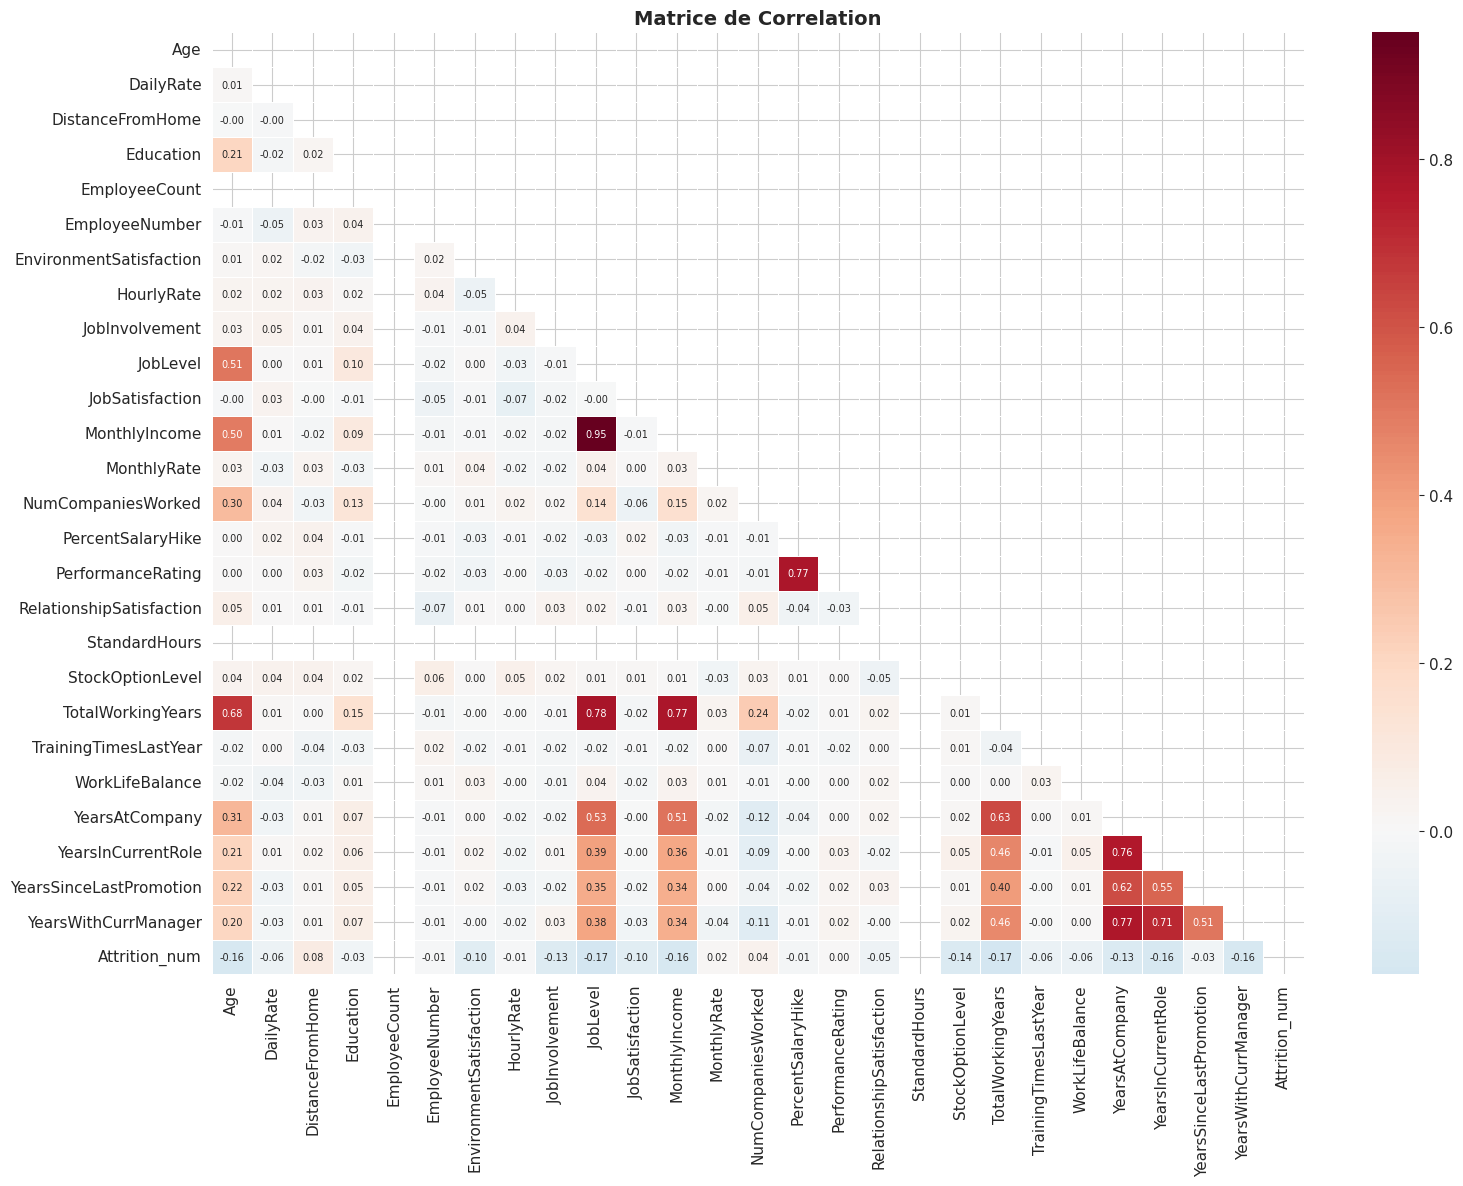

In [ ]:
# Matrice de correlation
df_num = df.select_dtypes(include=[np.number]).copy()
df_num['Attrition_num'] = (df['Attrition'] == 'Yes').astype(int)

corr = df_num.corr()

plt.figure(figsize=(16, 12))
masque = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=masque,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Matrice de Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

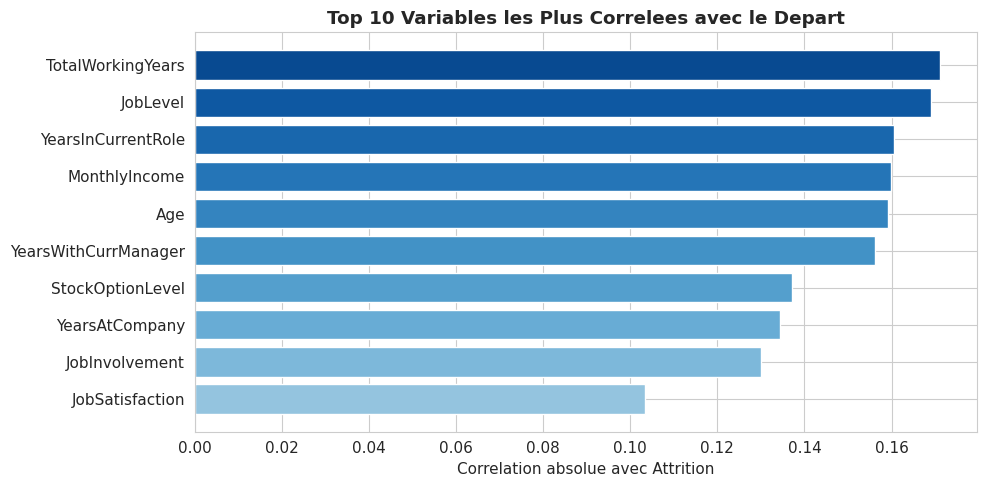

In [ ]:
# Top 10 variables les plus correlees avec la variable cible
top_corr = (
    corr['Attrition_num']
    .drop('Attrition_num')
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(
    top_corr.index[::-1],
    top_corr.values[::-1],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, 10))
)
plt.xlabel('Correlation absolue avec Attrition')
plt.title('Top 10 Variables les Plus Correlees avec le Depart', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etape 4 - Pretraitement des Donnees

In [ ]:
# Copie du dataset original
df_prep = df.copy()

# Encodage de la variable cible : Yes -> 1, No -> 0
df_prep['Attrition'] = (df_prep['Attrition'] == 'Yes').astype(int)

# Suppression des colonnes constantes (aucune information utile)
colonnes_a_supprimer = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_prep.drop(columns=colonnes_a_supprimer, inplace=True)

print(f'Colonnes supprimees : {colonnes_a_supprimer}')
print(f'Dimensions apres suppression : {df_prep.shape}')

Colonnes supprimees : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Dimensions apres suppression : (1470, 31)


In [ ]:
# Encodage des variables categorielles avec LabelEncoder
colonnes_cat = df_prep.select_dtypes(include=['object']).columns.tolist()
print(f'Variables categorielles a encoder : {colonnes_cat}')

le = LabelEncoder()
for col in colonnes_cat:
    df_prep[col] = le.fit_transform(df_prep[col])

print(f'{len(colonnes_cat)} variables encodees avec succes.')

Variables categorielles a encoder : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
7 variables encodees avec succes.


In [ ]:
# Separation des features (X) et de la variable cible (y)
X = df_prep.drop('Attrition', axis=1)
y = df_prep['Attrition']

noms_features = X.columns.tolist()

print(f'Dimensions X : {X.shape}')
print(f'Dimensions y : {y.shape}')
print(f'Distribution y -> Reste (0): {(y == 0).sum()} | Depart (1): {(y == 1).sum()}')

Dimensions X : (1470, 30)
Dimensions y : (1470,)
Distribution y -> Reste (0): 1233 | Depart (1): 237


In [ ]:
# Division en ensemble d'entrainement (80%) et de test (20%)
# stratify=y garantit la meme proportion de classes dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Ensemble entrainement : {X_train.shape[0]} lignes')
print(f'Ensemble test         : {X_test.shape[0]} lignes')

Ensemble entrainement : 1176 lignes
Ensemble test         : 294 lignes


In [ ]:
# Application de SMOTE sur l'ensemble d'entrainement uniquement
# SMOTE cree des exemples synthetiques de la classe minoritaire (departs)
print(f'Avant SMOTE -> Reste: {(y_train == 0).sum()} | Depart: {(y_train == 1).sum()}')

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'Apres SMOTE -> Reste: {(y_train_sm == 0).sum()} | Depart: {(y_train_sm == 1).sum()}')
print('Classes equilibrees avec succes.')

Avant SMOTE -> Reste: 986 | Depart: 190
Apres SMOTE -> Reste: 986 | Depart: 986
Classes equilibrees avec succes.


In [ ]:
# Normalisation avec StandardScaler
# fit sur train, transform sur train et test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print('Normalisation appliquee (StandardScaler).')

Normalisation appliquee (StandardScaler).


---
## Etape 5 - Modelisation

In [ ]:
# Definition des modeles a comparer
modeles = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'              : XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM'             : LGBMClassifier(random_state=42, verbose=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

print(f'{len(modeles)} modeles definis.')

5 modeles definis.


In [ ]:
# Entrainement de tous les modeles avec validation croisee (k=5)
resultats = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nom, modele in modeles.items():
    # Entrainement sur les donnees SMOTE
    modele.fit(X_train_scaled, y_train_sm)

    # Predictions sur l'ensemble de test
    y_pred  = modele.predict(X_test_scaled)
    y_proba = modele.predict_proba(X_test_scaled)[:, 1]

    # Validation croisee sur l'AUC-ROC
    scores_cv = cross_val_score(
        modele, X_train_scaled, y_train_sm,
        cv=cv, scoring='roc_auc'
    )

    resultats[nom] = {
        'modele'    : modele,
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
        'f1'        : f1_score(y_test, y_pred),
        'auc_roc'   : roc_auc_score(y_test, y_proba),
        'cv_mean'   : scores_cv.mean(),
        'cv_std'    : scores_cv.std(),
    }

    print(
        f'{nom:25s} | '
        f'AUC-ROC: {resultats[nom]["auc_roc"]:.4f} | '
        f'F1: {resultats[nom]["f1"]:.4f} | '
        f'Recall: {resultats[nom]["recall"]:.4f} | '
        f'CV: {scores_cv.mean():.4f} (+/- {scores_cv.std():.4f})'
    )

print('\nEntrainement de tous les modeles termine.')

Logistic Regression       | AUC-ROC: 0.7182 | F1: 0.4486 | Recall: 0.5106 | CV: 0.9139 (+/- 0.0156)
Random Forest             | AUC-ROC: 0.7346 | F1: 0.3059 | Recall: 0.2766 | CV: 0.9684 (+/- 0.0099)
XGBoost                   | AUC-ROC: 0.7411 | F1: 0.3855 | Recall: 0.3404 | CV: 0.9698 (+/- 0.0055)
LightGBM                  | AUC-ROC: 0.7521 | F1: 0.3765 | Recall: 0.3404 | CV: 0.9705 (+/- 0.0062)
Gradient Boosting         | AUC-ROC: 0.7633 | F1: 0.4694 | Recall: 0.4894 | CV: 0.9617 (+/- 0.0086)

Entrainement de tous les modeles termine.


---
## Etape 6 - Evaluation et Comparaison des Modeles

In [ ]:
# Tableau comparatif des metriques de tous les modeles
tableau_metriques = pd.DataFrame(
    {
        nom: {
            'Accuracy' : round(r['accuracy'],  4),
            'Precision': round(r['precision'], 4),
            'Recall'   : round(r['recall'],    4),
            'F1-Score' : round(r['f1'],        4),
            'AUC-ROC'  : round(r['auc_roc'],   4),
            'CV Mean'  : round(r['cv_mean'],   4),
        }
        for nom, r in resultats.items()
    }
).T.sort_values('AUC-ROC', ascending=False)

print('Tableau comparatif des modeles (trie par AUC-ROC decroissant) :')
print(tableau_metriques.to_string())

Tableau comparatif des modeles (trie par AUC-ROC decroissant) :
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  CV Mean
Gradient Boosting      0.8231     0.4510  0.4894    0.4694   0.7633   0.9617
LightGBM               0.8197     0.4211  0.3404    0.3765   0.7521   0.9705
XGBoost                0.8265     0.4444  0.3404    0.3855   0.7411   0.9698
Random Forest          0.7993     0.3421  0.2766    0.3059   0.7346   0.9684
Logistic Regression    0.7993     0.4000  0.5106    0.4486   0.7182   0.9139


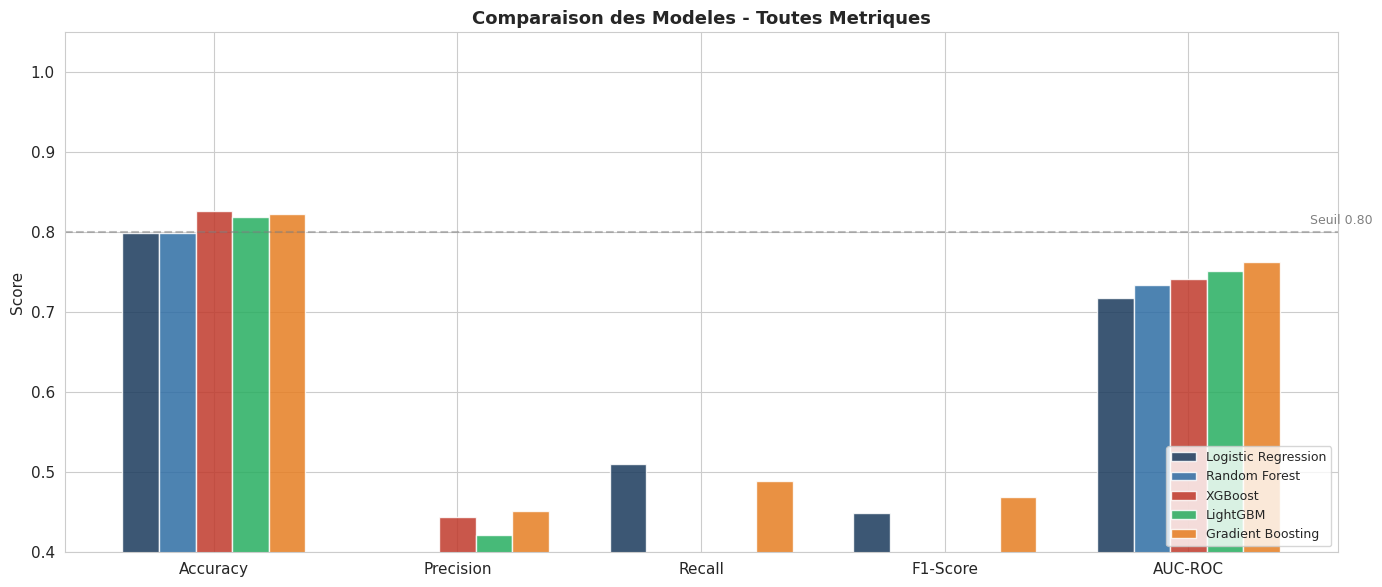

In [ ]:
# Graphique comparatif des metriques
metriques_cles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metriques_cles))
largeur = 0.15
couleurs = ['#1a3a5c', '#2e6da4', '#c0392b', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (nom, r) in enumerate(resultats.items()):
    valeurs = [r['accuracy'], r['precision'], r['recall'], r['f1'], r['auc_roc']]
    ax.bar(x + i * largeur, valeurs, largeur, label=nom, color=couleurs[i], alpha=0.85)

ax.set_xticks(x + largeur * 2)
ax.set_xticklabels(metriques_cles)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des Modeles - Toutes Metriques', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
ax.text(4.8, 0.81, 'Seuil 0.80', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

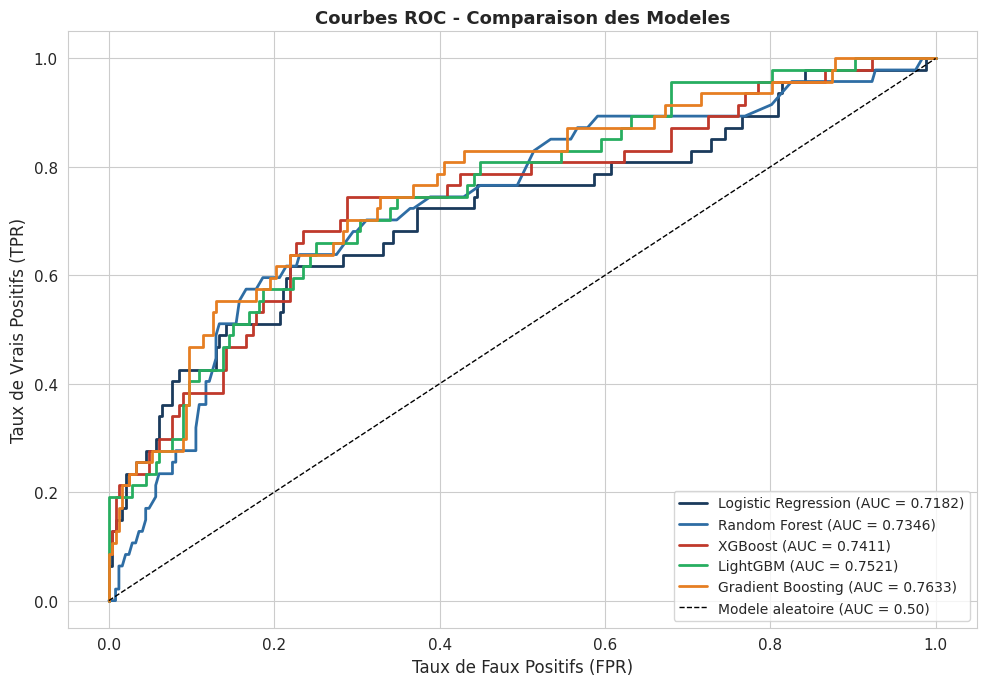

In [ ]:
# Courbes ROC de tous les modeles
plt.figure(figsize=(10, 7))

for i, (nom, r) in enumerate(resultats.items()):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(
        fpr, tpr,
        color=couleurs[i], linewidth=2,
        label=f"{nom} (AUC = {r['auc_roc']:.4f})"
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Modele aleatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Comparaison des Modeles', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Selection du meilleur modele selon l'AUC-ROC
meilleur_nom = max(resultats, key=lambda k: resultats[k]['auc_roc'])
meilleur = resultats[meilleur_nom]

print(f'Meilleur modele : {meilleur_nom}')
print(f'  AUC-ROC   : {meilleur["auc_roc"]:.4f}')
print(f'  Recall    : {meilleur["recall"]:.4f}')
print(f'  F1-Score  : {meilleur["f1"]:.4f}')
print(f'  Precision : {meilleur["precision"]:.4f}')
print(f'  Accuracy  : {meilleur["accuracy"]:.4f}')

Meilleur modele : Gradient Boosting
  AUC-ROC   : 0.7633
  Recall    : 0.4894
  F1-Score  : 0.4694
  Precision : 0.4510
  Accuracy  : 0.8231


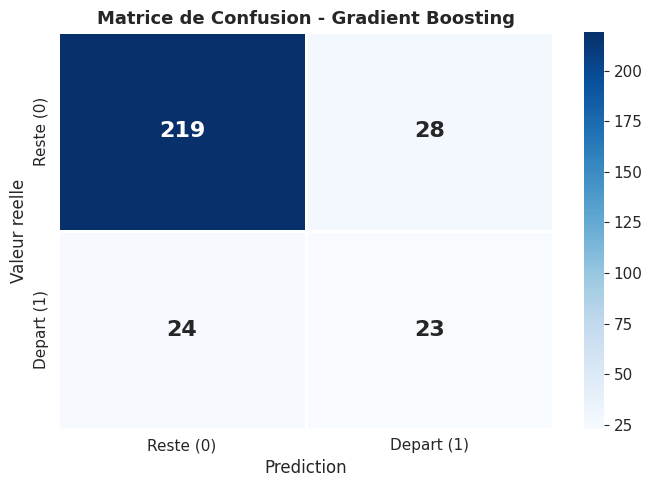


Rapport de classification complet :
              precision    recall  f1-score   support

       Reste       0.90      0.89      0.89       247
      Depart       0.45      0.49      0.47        47

    accuracy                           0.82       294
   macro avg       0.68      0.69      0.68       294
weighted avg       0.83      0.82      0.83       294



In [ ]:
# Matrice de confusion du meilleur modele
cm = confusion_matrix(y_test, meilleur['y_pred'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Reste (0)', 'Depart (1)'],
    yticklabels=['Reste (0)', 'Depart (1)'],
    linewidths=2, linecolor='white',
    ax=ax, annot_kws={'size': 16, 'weight': 'bold'}
)
ax.set_xlabel('Prediction', fontsize=12)
ax.set_ylabel('Valeur reelle', fontsize=12)
ax.set_title(f'Matrice de Confusion - {meilleur_nom}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRapport de classification complet :')
print(classification_report(y_test, meilleur['y_pred'], target_names=['Reste', 'Depart']))

---
## Etape 7 - Interpretabilite avec SHAP

In [ ]:
# Calcul des valeurs SHAP pour le meilleur modele
# TreeExplainer est optimise pour les modeles bases sur des arbres de decision
meilleur_modele = meilleur['modele']

X_test_df = pd.DataFrame(X_test_scaled, columns=noms_features)

explainer  = shap.TreeExplainer(meilleur_modele)
shap_vals  = explainer.shap_values(X_test_df)

# Pour les modeles de classification binaire, selectionner la classe 1 (depart)
if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals

print('Valeurs SHAP calculees avec succes.')

Valeurs SHAP calculees avec succes.


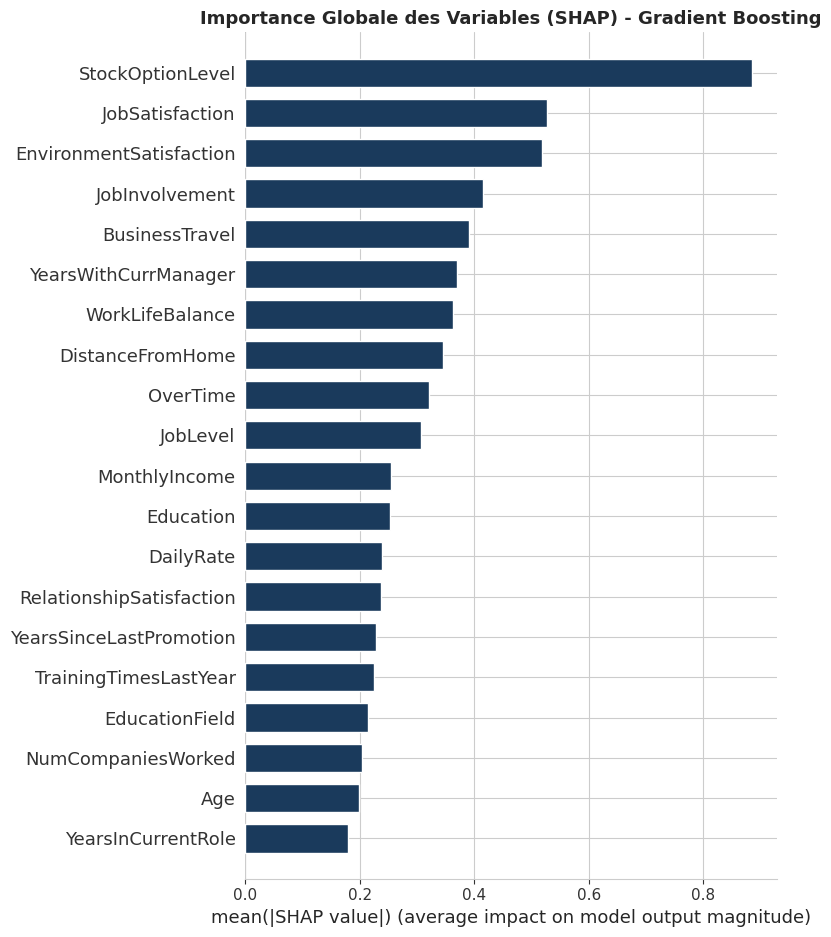

In [ ]:
# Importance globale des variables (SHAP bar plot)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_test_df,
    feature_names=noms_features,
    plot_type='bar',
    show=False,
    color='#1a3a5c'
)
plt.title(
    f'Importance Globale des Variables (SHAP) - {meilleur_nom}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

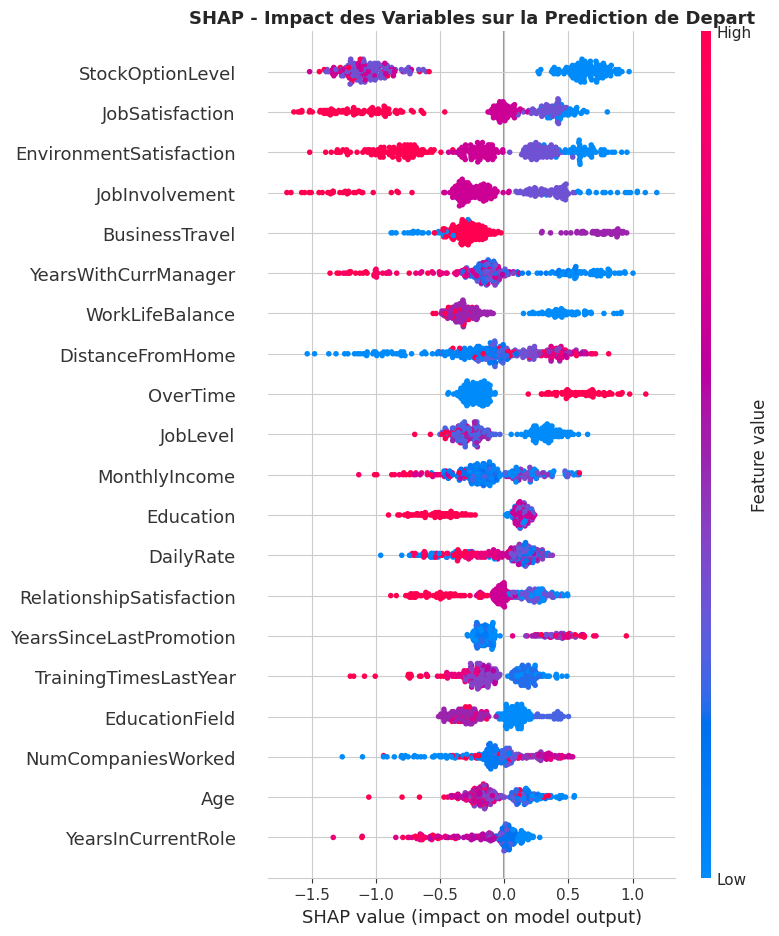

In [ ]:
# Beeswarm plot SHAP - impact et direction de chaque variable
# Rouge = valeur elevee de la variable, Bleu = valeur faible
# Axe X positif = augmente le risque de depart
shap.summary_plot(
    sv, X_test_df,
    feature_names=noms_features,
    show=False
)
plt.title(
    'SHAP - Impact des Variables sur la Prediction de Depart',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

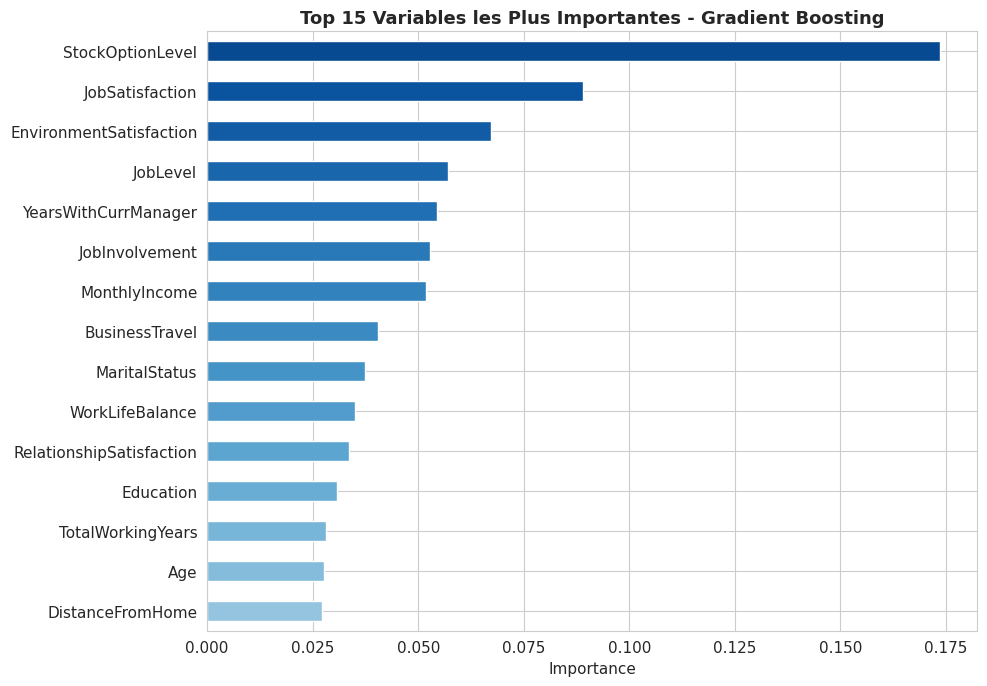

Top 5 facteurs predisant le depart :
  1. StockOptionLevel               : 0.1736
  2. JobSatisfaction                : 0.0890
  3. EnvironmentSatisfaction        : 0.0674
  4. JobLevel                       : 0.0570
  5. YearsWithCurrManager           : 0.0545


In [ ]:
# Importance des variables du modele (feature importance interne)
if hasattr(meilleur_modele, 'feature_importances_'):
    importance = pd.Series(
        meilleur_modele.feature_importances_,
        index=noms_features
    ).sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    importance.plot(
        kind='barh', ax=ax,
        color=plt.cm.Blues(np.linspace(0.4, 0.9, len(importance)))
    )
    ax.set_title(
        f'Top 15 Variables les Plus Importantes - {meilleur_nom}',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print('Top 5 facteurs predisant le depart :')
    top5 = pd.Series(
        meilleur_modele.feature_importances_,
        index=noms_features
    ).sort_values(ascending=False).head(5)
    for rang, (feat, val) in enumerate(top5.items(), 1):
        print(f'  {rang}. {feat:30s} : {val:.4f}')

---
## Etape 8 - Recommandations Metier

In [ ]:
# Synthese finale des resultats
print('=' * 65)
print('   SYNTHESE FINALE - PROJET N14')
print('   Prediction du Turnover des Auditeurs Internes')
print('   ENCG Settat - Option CAC - Module IA')
print('=' * 65)

print(f'\nMEILLEUR MODELE : {meilleur_nom}')
print(f'  AUC-ROC  : {meilleur["auc_roc"]:.4f}')
print(f'  Recall   : {meilleur["recall"]:.4f}  (capacite a detecter les departs reels)')
print(f'  F1-Score : {meilleur["f1"]:.4f}')

print('\nTOP 5 FACTEURS PREDICTIFS DU DEPART :')
top5_finale = pd.Series(
    meilleur_modele.feature_importances_,
    index=noms_features
).sort_values(ascending=False).head(5)

for rang, feat in enumerate(top5_finale.index, 1):
    print(f'  {rang}. {feat}')

print('\nRECOMMANDATIONS POUR LES CABINETS D\'AUDIT MAROCAINS :')
recommandations = [
    'Surveiller les auditeurs effectuant frequemment des heures supplementaires (OverTime)',
    'Proposer des plans de carriere clairs et des perspectives d\'evolution rapides',
    'Ameliorer l\'equilibre vie professionnelle / vie personnelle (WorkLifeBalance)',
    'Aligner la politique de remuneration (MonthlyIncome) avec les standards du marche',
    'Renforcer les programmes de formation continue (CPD - OECCA Maroc)',
    'Mettre en place des entretiens de retention pour les profils identifies a risque',
    'Reduire la distance domicile-cabinet pour les missions sur site (DistanceFromHome)',
]
for i, r in enumerate(recommandations, 1):
    print(f'  {i}. {r}')

print('\n' + '=' * 65)

   SYNTHESE FINALE - PROJET N14
   Prediction du Turnover des Auditeurs Internes
   ENCG Settat - Option CAC - Module IA

MEILLEUR MODELE : Gradient Boosting
  AUC-ROC  : 0.7633
  Recall   : 0.4894  (capacite a detecter les departs reels)
  F1-Score : 0.4694

TOP 5 FACTEURS PREDICTIFS DU DEPART :
  1. StockOptionLevel
  2. JobSatisfaction
  3. EnvironmentSatisfaction
  4. JobLevel
  5. YearsWithCurrManager

RECOMMANDATIONS POUR LES CABINETS D'AUDIT MAROCAINS :
  1. Surveiller les auditeurs effectuant frequemment des heures supplementaires (OverTime)
  2. Proposer des plans de carriere clairs et des perspectives d'evolution rapides
  3. Ameliorer l'equilibre vie professionnelle / vie personnelle (WorkLifeBalance)
  4. Aligner la politique de remuneration (MonthlyIncome) avec les standards du marche
  5. Renforcer les programmes de formation continue (CPD - OECCA Maroc)
  6. Mettre en place des entretiens de retention pour les profils identifies a risque
  7. Reduire la distance domicile

In [ ]:
# Simulation : prediction pour un employe individuel
# Utilisation du premier exemple de l'ensemble de test
exemple = X_test_scaled[:1]
prediction    = meilleur_modele.predict(exemple)[0]
probabilite   = meilleur_modele.predict_proba(exemple)[0][1]

print('SIMULATION - Prediction pour un auditeur individuel')
print('-' * 50)
print(f'Probabilite de depart : {probabilite * 100:.1f}%')
print(f'Prediction            : {"DEPART PROBABLE" if prediction == 1 else "RESTE"}')

if probabilite > 0.70:
    print('Action recommandee    : Entretien de retention URGENT')
elif probabilite > 0.40:
    print('Action recommandee    : Suivi rapproche et plan de developpement')
else:
    print('Action recommandee    : Aucune action urgente necessaire')

SIMULATION - Prediction pour un auditeur individuel
--------------------------------------------------
Probabilite de depart : 64.7%
Prediction            : DEPART PROBABLE
Action recommandee    : Suivi rapproche et plan de developpement


---

## Conclusion

Ce projet a demontre l'application du Machine Learning pour resoudre un probleme RH concret dans le contexte des cabinets d'audit et des directions d'audit interne au Maroc.

### Recapitulatif des etapes

| Etape | Description |
|-------|-------------|
| 1 | Installation et importation des bibliotheques |
| 2 | Chargement du dataset IBM HR Analytics |
| 3 | Exploration (EDA) : distributions, correlations, boxplots |
| 4 | Pretraitement : encodage, SMOTE, normalisation |
| 5 | Modelisation : 5 modeles entraines avec validation croisee |
| 6 | Evaluation : AUC-ROC, F1, Recall, matrice de confusion, courbes ROC |
| 7 | Interpretabilite : SHAP values, feature importance |
| 8 | Recommandations metier et simulation individuelle |

### Outils utilises

Python - Scikit-learn - XGBoost - LightGBM - SHAP - SMOTE (imbalanced-learn) - Seaborn - Matplotlib - Pandas - NumPy

---

*ENCG Settat - Module Intelligence Artificielle - Option Controle, Audit et Conseil - 2025/2026*